In [33]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Step1: Load the data

In [12]:
def load_cleaned_data(station_id, directory="../EDA_2025/cleaned_data"):
    filename = f"{directory}/Station{station_id}_cleaned_data.csv"
    df = pd.read_csv(filename, parse_dates=True, index_col=0)
    df.index = pd.DatetimeIndex(df.index)
    df.index.freq = 'H'
    return df

def load_missing_data(station_id, directory="../EDA_2025/missing_data"):
    filename = f"{directory}/Station{station_id}_missing_data.csv"
    df = pd.read_csv(filename, parse_dates=["Start Timestamp", "End Timestamp"])
    return df

### Step2: Filter Short gap data (Hours to Days) (<24 hours)

In [4]:
def filter_short_gaps(gap_df, parameter, max_gap = 24):
    gap_df["Number Missing"] = pd.to_numeric(gap_df["Number Missing"], errors="coerce")
    mask = (gap_df["Parameter"] == parameter) & (gap_df["Number Missing"] < max_gap)
    return gap_df[mask].copy()

### Method 1: Interpolation

In [5]:
def fill_by_interpolation(series, start_ts, end_ts):
    s = series.copy()
    s[start_ts:end_ts] = np.nan
    s = s.interpolate(method="time")
    return s.loc[start_ts:end_ts]

### Method 2: Moving Average

In [27]:
#def fill_by_moving_average(series, start_ts, end_ts, window = 3):
    #before = series.loc[start_ts - pd.Timedelta(hours=window): start_ts - pd.Timedelta(hours=1)].dropna()
    #after  = series.loc[end_ts   + pd.Timedelta(hours=1): end_ts   + pd.Timedelta(hours=window)].dropna()
    #combined = pd.concat([before, after])

    #if combined.empty:
        #fill_val = series.loc[: start_ts - pd.Timedelta(hours=1)].iloc[-1]
    #else:
        #fill_val = combined.mean()
        
    #idx = pd.date_range(start_ts, end_ts, freq="H")
    #return pd.Series(fill_val, index=idx)

### Step 4: Evaluate two methods

In [39]:
def plot_gap(series, start_ts, end_ts, interp_vals, window = 6):
    plt.figure(figsize=(9,3))
    plt.plot(series[start_ts - pd.Timedelta(hours=window):
                    end_ts   + pd.Timedelta(hours=window)],
             label="Original", color="black")
    plt.plot(interp_vals, color="red", lw=2, label="Interpolation")
    plt.axvspan(start_ts, end_ts, color="gray", alpha=0.25)
    plt.title(f"Gap {start_ts} → {end_ts}")
    plt.legend(); plt.tight_layout(); plt.show()

In [37]:
def main(station_id = 1, parameter = "SWC_20"):
    df = load_cleaned_data(station_id)
    gaps = load_missing_data(station_id)
    short_gaps = filter_short_gaps(gaps, parameter)

    if short_gaps.empty:
        print(f"No short gaps (<24 h) for {parameter} at station {station_id}.")
        return

    print(f"Found {len(short_gaps)} short gaps for {parameter}. ")

    for _, row in short_gaps.iterrows():
        start_ts = pd.to_datetime(row["Start Timestamp"])
        end_ts   = pd.to_datetime(row["End Timestamp"])

        interp_vals = fill_by_interpolation(df[parameter], start_ts, end_ts)
        df.loc[start_ts:end_ts, parameter] = interp_vals
        plot_gap(df[parameter], start_ts, end_ts, interp_vals)


Found 8 short gaps for SWC_20. 


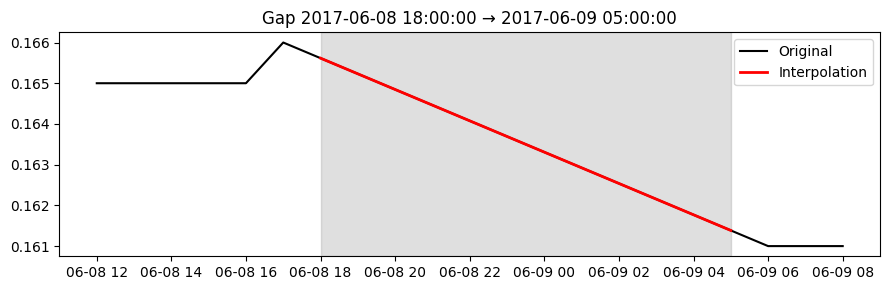

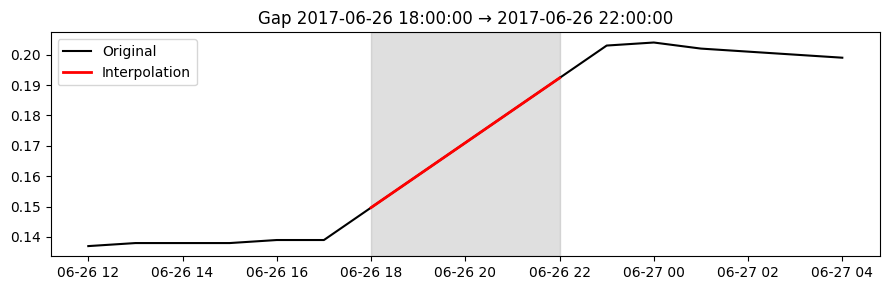

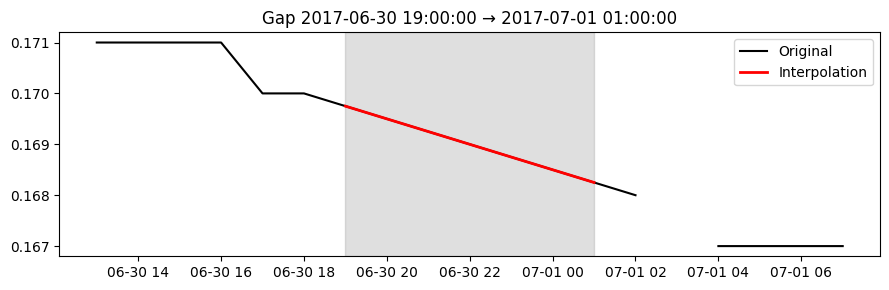

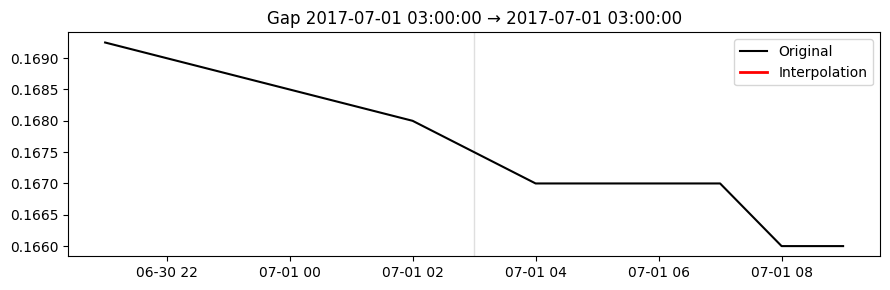

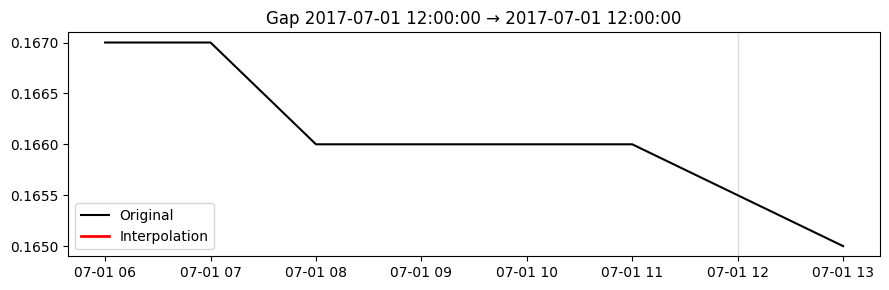

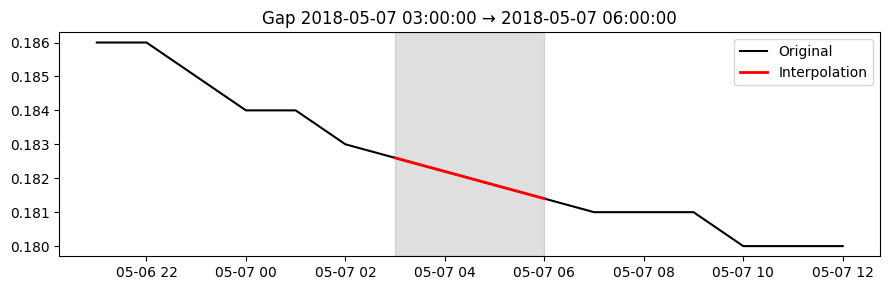

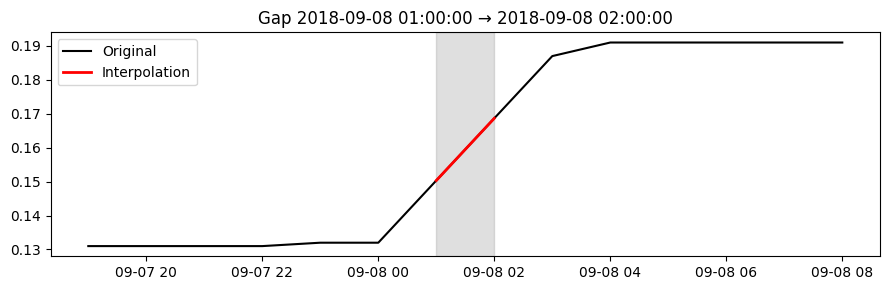

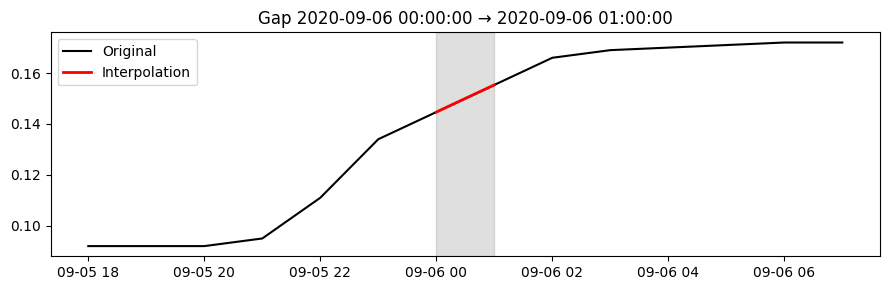


Done. Interpolated file saved to: Station1_SWC_20_filled_shortgaps.csv


In [40]:
main(station_id=1, parameter="SWC_20")

In [10]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ---------- 参数 ----------
STATIONS   = [1, 2, 3, 4, 5, 6]     # 也可用 glob 自动发现
PARAM      = "SWC_50"
N_GAPS     = 10
GAP_H_MIN  = 4
GAP_H_MAX  = 12
rng        = np.random.default_rng(42)

# ---------- 工具函数 ----------
def load_cleaned_data(station_id, directory="../EDA_2025/cleaned_data"):
    fn = Path(directory) / f"Station{station_id}_cleaned_data.csv"
    df = pd.read_csv(fn, parse_dates=True, index_col=0)
    df.index = pd.DatetimeIndex(df.index, freq="H")
    return df

def punch_and_fill(series, n_gaps, rng):
    s_gap   = series.copy()
    all_ts  = s_gap.index[~s_gap.isna()]
    punched = []

    # punch synthetic gaps
    while len(punched) < n_gaps:
        start = rng.choice(all_ts[:-GAP_H_MAX])
        gap_len = rng.integers(GAP_H_MIN, GAP_H_MAX + 1)
        end = start + pd.Timedelta(hours=gap_len - 1)
        idx = pd.date_range(start, end, freq="H")
        if s_gap.loc[idx].isna().any():
            continue
        punched.append((idx, s_gap.loc[idx].values.copy()))
        s_gap.loc[idx] = np.nan

    # interpolate
    s_filled = s_gap.interpolate(method="time")

    # metrics
    maes, mses, rmses = [], [], []
    for idx, true_vals in punched:
        pred_vals = s_filled.loc[idx].values
        maes.append(mean_absolute_error(true_vals, pred_vals))
        mses.append(mean_squared_error(true_vals, pred_vals))
        rmses.append(mean_squared_error(true_vals, pred_vals, squared=False))
    return np.mean(maes), np.mean(mses), np.mean(rmses)

# ---------- 主循环 ----------
results = []
for sid in STATIONS:
    df = load_cleaned_data(sid)
    mae, mse, rmse = punch_and_fill(df[PARAM], N_GAPS, rng)
    results.append({"Station": sid, "MAE": mae, "MSE": mse, "RMSE": rmse})

res_df = pd.DataFrame(results)
display(res_df)  

print("\nOverall average across all stations")
print(res_df[["MAE", "MSE", "RMSE"]].mean())


C:\Users\13464\miniconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\13464\miniconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\13464\miniconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\13464\miniconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use 

,Station,MAE,MSE,RMSE
0,1,0.000190,9.696849e-08,0.000236
1,2,0.000183,1.098459e-07,0.000209
2,3,0.000183,9.277325e-08,0.000213
3,5,0.000165,1.480148e-07,0.000182
4,6,0.000152,6.099387e-08,0.000174



Overall average across all stations
MAE     1.745916e-04
MSE     1.017193e-07
RMSE    2.027548e-04
dtype: float64
